In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap

#Load File Path and PME Label Column
os.chdir('/home/goel107/GPCRs/GPCR_PME-ML-v3/')
DATA_PATH = 'GPCR_TRANSCRIPT_PROTEIN_FEATURES.csv'
PME_COLUMN = 'GPCR_PME' 

# Load the main dataframe
gpcr_df = pd.read_csv(DATA_PATH)


# Fetch subsets of CSV relevant to analyses
feature_cols = ['relative_tmd_1', 'relative_tmd_2', 'relative_tmd_3', 'relative_tmd_4', 'relative_tmd_5', 'relative_tmd_6', 'relative_tmd_7',
    'relative_N_terminal_loop_length', 'relative_downstream_loop_length_1', 'relative_upstream_loop_length_1',
    'relative_downstream_loop_length_2', 'relative_upstream_loop_length_2', 'relative_downstream_loop_length_3',
    'relative_upstream_loop_length_3', 'relative_C_terminal_loop_length', 'Molecular_Weight', 'Isoelectric_Point', 'Aromaticity', 'instability_index', 'gravy',
    'sasa_total', 'sasa_crg', 'sasa_plr', 'sasa_aplr', 'f_crg', 'f_plr', 'f_aplr', 'alpha_helix', '3_10_helix', 'extended_configuration', 
    'isolated_beta_bridge', 'turn', 'coil', 'adjusted_tmd_delta_G_1', 'adjusted_tmd_delta_G_2', 'adjusted_tmd_delta_G_3', 'adjusted_tmd_delta_G_4',
    'adjusted_tmd_delta_G_5', 'adjusted_tmd_delta_G_6', 'adjusted_tmd_delta_G_7',
    'CAI', 'Nc', 'GC3s', 'CpG_frame1_2', 'avgCU', 'CPS_sum', 'CPSpL', 'Global_tAI', 'tAI10Min', 'tAI10Max', 'tAI10q25.25.',
    'tAI10q75.75.', 'avgCU_first20', 'avgCU_first10', 'avgCU_first5', 'GC', 'GC10min', 'GC10q25', 'GC10q75', 'GC10max',
    'X40deltaG', 'X40freqens', 'plus10valRNAss', 'zeroto38avgRNAss', 'zeroto38minRNAss', 'zeroto38q25RNAss', 
    'zeroto38q75RNAss', 'zeroto38maxRNAss', 'deltaG', 'freqens', 'avgRNAss', 'minRNAss', 'q25RNAss', 'q75RNAss', 'maxRNAss']

# Build feature matrix
X = gpcr_df[feature_cols]

#Drop rows with NaNs once
mask = X.notna().all(axis=1)

X_clean = X.loc[mask]
gpcr_df_clean = gpcr_df.loc[mask].copy()

/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


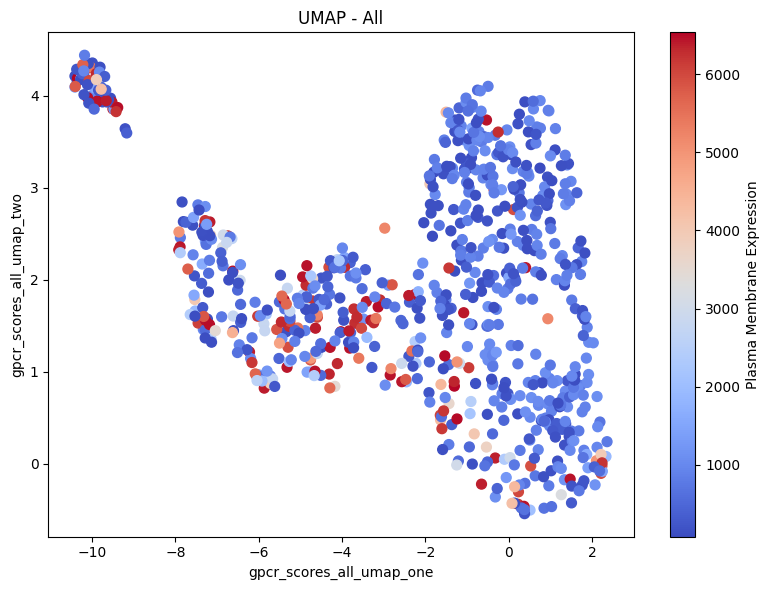

In [2]:
#Scale the Dataset to Be Analyzed
scaled_X = StandardScaler().fit_transform(X_clean)

#Load the UMAP Object from the Library 
reducer = umap.UMAP(random_state=42)

#Obtain UMAP Embeddings from Dataset
embedding = reducer.fit_transform(scaled_X)

#Save Two Dimensions from the UMAP to the DataFrame
gpcr_df_clean['gpcr_scores_all_umap_one'] = embedding[:,0]
gpcr_df_clean['gpcr_scores_all_umap_two'] = embedding[:,1]

# Write table to Excel sheet and start seeing if you have any clustering behavior
gpcr_df_clean.to_excel(
    'gpcr_dim_reduction-umap.xlsx',
    sheet_name='data',
    index=False
)

# Define a dictionary of UMAP column name pairs and corresponding plot titles
umap_column_sets = {'gpcr_scores_all': 'UMAP - All'}

# Plotting function (already defined)
def plot_umap_scatter(df, x_col, y_col, color_col, title):
    x = df[x_col]
    y = df[y_col]
    color = df[color_col]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(x, y, c=color, cmap='coolwarm', s=50)
    plt.colorbar(scatter, label='Plasma Membrane Expression')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot all UMAPs
for prefix, title in umap_column_sets.items():
    x_col = f'{prefix}_umap_one'
    y_col = f'{prefix}_umap_two'
    
    # Make sure the columns exist before plotting
    if x_col in gpcr_df_clean.columns and y_col in gpcr_df_clean.columns:
        plot_umap_scatter(gpcr_df_clean, x_col=x_col, y_col=y_col, color_col=PME_COLUMN, title=title)
    else:
        print(f"Skipping {prefix} — UMAP columns not found.")